In [1]:
import pandas as pd

# Membaca file CSV 
df = pd.read_csv('Data_Depresi.csv', sep=";")

# Menghapus baris yang seluruh kolomnya kosong/NaN
df = df.dropna(how='all')

# Menampilkan 5 baris data teratas
df.head(5)

,Nama,Suhu Tubuh,BPM,SpO2,Waktu Tidur,Psikologi_1,Psikologi_2,Psikologi_3,Psikologi_4,Psikologi_5,Psikologi_6,Psikologi_7,Psikologi_8,Psikologi_9,Psikologi_10,PSS Scale,Level Depresi Berdasarkan Parameter Fisis,Level Depresi Berdasarkan Parameter Psikologi,Level Depresi
0,Participant 1,"36,8","108,2","60,08",6,3.0,2.0,2.0,3.0,2.0,1.0,1.0,3.0,2.0,2.0,21.0,2.0,2.0,2.0
1,Participant 2,"36,7","103,4",94,5,4.0,4.0,3.0,2.0,2.0,2.0,0.0,2.0,3.0,1.0,23.0,2.0,2.0,2.0
2,Participant 3,"36,35","94,2",98,"5,5",3.0,3.0,2.0,2.0,1.0,3.0,1.0,2.0,4.0,2.0,23.0,1.0,2.0,2.0
3,Participant 4,35,"102,8","97,2",5,3.0,2.0,3.0,2.0,3.0,2.0,2.0,3.0,3.0,2.0,25.0,2.0,2.0,2.0
4,Participant 5,"35,45",84,"95,4",7,1.0,2.0,1.0,1.0,3.0,2.0,3.0,2.0,3.0,1.0,19.0,1.0,2.0,2.0


In [2]:
# Tentukan kolom apa saja yang mau kamu sisakan
filter_data = ['Psikologi_1', 'Psikologi_2', 'Psikologi_3', 'Psikologi_4', 'Psikologi_5', 'Psikologi_6', 'Psikologi_7', 'Psikologi_8', 'Psikologi_9', 'Psikologi_10']

# Filter dataframe dan langsung timpa ke variabel df
df = df[filter_data]

# Menampilkan 5 baris data teratas
df.head(5)

,Psikologi_1,Psikologi_2,Psikologi_3,Psikologi_4,Psikologi_5,Psikologi_6,Psikologi_7,Psikologi_8,Psikologi_9,Psikologi_10
0,3.0,2.0,2.0,3.0,2.0,1.0,1.0,3.0,2.0,2.0
1,4.0,4.0,3.0,2.0,2.0,2.0,0.0,2.0,3.0,1.0
2,3.0,3.0,2.0,2.0,1.0,3.0,1.0,2.0,4.0,2.0
3,3.0,2.0,3.0,2.0,3.0,2.0,2.0,3.0,3.0,2.0
4,1.0,2.0,1.0,1.0,3.0,2.0,3.0,2.0,3.0,1.0


In [3]:
import numpy as np

# 1. Pastikan data disalin ke DataFrame baru untuk menghindari SettingWithCopyWarning
df_pss = df[filter_data].copy()

# 2. Proses Reverse Scoring untuk kolom 4, 5, 7, dan 8 
kolom_reverse = ["Psikologi_4", "Psikologi_5", "Psikologi_7", "Psikologi_8"]
for col in kolom_reverse:
    df_pss[col] = 4 - df_pss[col]

# 3. Menghitung Total PSS Score (Menjumlahkan semua kolom Psikologi_1 sampai Psikologi_10)
df_pss["Total_PSS_Score"] = df_pss[filter_data].sum(axis=1)


# 4. Menentukan Level Stress berdasarkan rentang nilai menggunakan np.select
# Kondisi rentang skor
kondisi = [
    (df_pss["Total_PSS_Score"] >= 0) & (df_pss["Total_PSS_Score"] <= 13),
    (df_pss["Total_PSS_Score"] >= 14) & (df_pss["Total_PSS_Score"] <= 26),
    (df_pss["Total_PSS_Score"] >= 27) & (df_pss["Total_PSS_Score"] <= 40),
]

# Label untuk masing-masing kondisi
pilihan_level = ["Low Stress", "Moderate Stress", "High Perceived Stress"]

df_pss["Stress_Level"] = np.select(kondisi, pilihan_level, default="Invalid Score")

df_pss.head(5)

,Psikologi_1,Psikologi_2,Psikologi_3,Psikologi_4,Psikologi_5,Psikologi_6,Psikologi_7,Psikologi_8,Psikologi_9,Psikologi_10,Total_PSS_Score,Stress_Level
0,3.0,2.0,2.0,1.0,2.0,1.0,3.0,1.0,2.0,2.0,19.0,Moderate Stress
1,4.0,4.0,3.0,2.0,2.0,2.0,4.0,2.0,3.0,1.0,27.0,High Perceived Stress
2,3.0,3.0,2.0,2.0,3.0,3.0,3.0,2.0,4.0,2.0,27.0,High Perceived Stress
3,3.0,2.0,3.0,2.0,1.0,2.0,2.0,1.0,3.0,2.0,21.0,Moderate Stress
4,1.0,2.0,1.0,3.0,1.0,2.0,1.0,2.0,3.0,1.0,17.0,Moderate Stress


In [4]:
# Menambahkan Kolom Nomor Urut ('No') di awal dataframe
df_pss.insert(0, "No", range(1, len(df_pss) + 1))

# Tampilkan 5 data teratas hasil transformasi
df_pss.head(5)

,No,Psikologi_1,Psikologi_2,Psikologi_3,Psikologi_4,Psikologi_5,Psikologi_6,Psikologi_7,Psikologi_8,Psikologi_9,Psikologi_10,Total_PSS_Score,Stress_Level
0,1,3.0,2.0,2.0,1.0,2.0,1.0,3.0,1.0,2.0,2.0,19.0,Moderate Stress
1,2,4.0,4.0,3.0,2.0,2.0,2.0,4.0,2.0,3.0,1.0,27.0,High Perceived Stress
2,3,3.0,3.0,2.0,2.0,3.0,3.0,3.0,2.0,4.0,2.0,27.0,High Perceived Stress
3,4,3.0,2.0,3.0,2.0,1.0,2.0,2.0,1.0,3.0,2.0,21.0,Moderate Stress
4,5,1.0,2.0,1.0,3.0,1.0,2.0,1.0,2.0,3.0,1.0,17.0,Moderate Stress


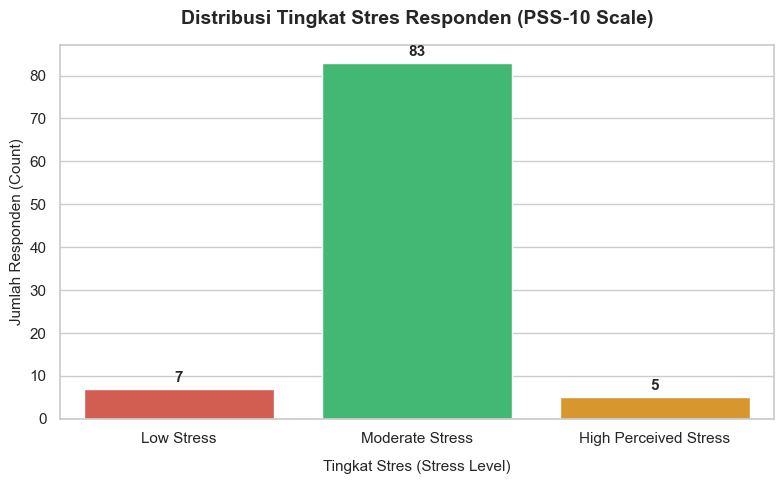

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Mengatur ukuran canvas grafik (lebar, tinggi)
plt.figure(figsize=(8, 5))

# 2. Mengatur tema visual agar terlihat bersih dan profesional
sns.set_theme(style="whitegrid")

# 3. Membuat bar chart berdasarkan urutan tingkat stres yang logis
urutan_level = ["Low Stress", "Moderate Stress", "High Perceived Stress"]

# Palette warna: Hijau (Low), Kuning/Oranye (Moderate), Merah (High)
warna_custom = ["#2ecc71", "#f39c12", "#e74c3c"]

ax = sns.countplot(
    data=df_pss,
    x="Stress_Level",
    order=urutan_level,
    palette=warna_custom,
    hue="Stress_Level",
    legend=False,
)

# 4. Menambahkan angka jumlah tepat di atas setiap batang (Bar Labels)
for p in ax.patches:
    ax.annotate(
        f"{int(p.get_height())}",
        (p.get_x() + p.get_width() / 2.0, p.get_height()),
        ha="center",
        va="center",
        xytext=(0, 8),
        textcoords="offset points",
        fontsize=11,
        weight="bold",
    )

# 5. Menambahkan Judul dan Label Kapasitas
plt.title(
    "Distribusi Tingkat Stres Responden (PSS-10 Scale)",
    fontsize=14,
    weight="bold",
    pad=15,
)
plt.xlabel("Tingkat Stres (Stress Level)", fontsize=11, labelpad=10)
plt.ylabel("Jumlah Responden (Count)", fontsize=11)

# 6. Merapikan tata letak grafik sebelum ditampilkan
plt.tight_layout()
plt.show()

In [6]:
# Mengambil nama kolom Psikologi_1 sampai Psikologi_10
kolom_psikologi = [f'Psikologi_{i}' for i in range(1, 11)]

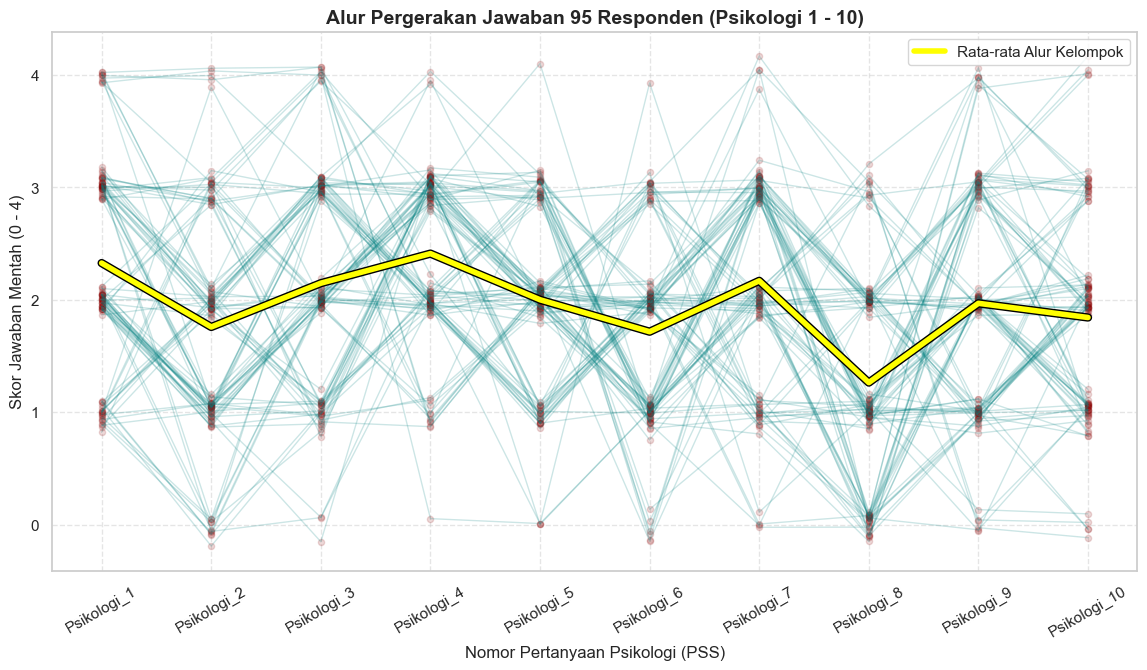

In [7]:
plt.figure(figsize=(14, 7))

# Menambahkan sedikit 'jitter' (noise acak kecil) HANYA untuk visualisasi scatter 
# agar titik yang bertumpuk di angka skala Likert (0-4) bisa terlihat sebarannya
df_visual = df_pss[kolom_psikologi].copy()
jitter = np.random.normal(0, 0.08, size=df_visual.shape)
df_jittered = df_visual + jitter

# Plot garis alur pergerakan emosi untuk setiap orang (95 responden)
for i in range(len(df_visual)):
    # alpha=0.20 membuat garis transparan, jika menumpuk akan terlihat semakin tebal/pekat
    plt.plot(kolom_psikologi, df_jittered.iloc[i], color='teal', alpha=0.20, linewidth=1)
    plt.scatter(kolom_psikologi, df_jittered.iloc[i], color='darkred', alpha=0.15, s=20)

# 1. Gambar garis latar belakang warna hitam yang lebih tebal sebagai pengganti 'edgecolor'
plt.plot(kolom_psikologi, df_visual.mean(), color='black', linewidth=6) 

# 2. Gambar garis utama warna kuning di atasnya (dengan linewidth sedikit lebih kecil)
plt.plot(kolom_psikologi, df_visual.mean(), color='yellow', linewidth=4, 
         label='Rata-rata Alur Kelompok')

# Pengaturan Estetika Grafik
plt.title('Alur Pergerakan Jawaban 95 Responden (Psikologi 1 - 10)', fontsize=14, fontweight='bold')
plt.xlabel('Nomor Pertanyaan Psikologi (PSS)', fontsize=12)
plt.ylabel('Skor Jawaban Mentah (0 - 4)', fontsize=12)
plt.yticks(range(5)) # Skala Likert 0 sampai 4
plt.grid(True, linestyle='--', alpha=0.5)
plt.xticks(rotation=30)
plt.legend(loc='upper right')

plt.show()

In [8]:
jawaban_flat = df_visual.apply(lambda x: x.nunique() == 1, axis=1).sum()

print("-" * 50)
print(f"HASIL DETEKSI JAWABAN FLAT:")
print(f"Jumlah responden yang menjawab angka SAMA PERSIS dari No. 1-10: {jawaban_flat} orang.")
print("-" * 50)

--------------------------------------------------
HASIL DETEKSI JAWABAN FLAT:
Jumlah responden yang menjawab angka SAMA PERSIS dari No. 1-10: 0 orang.
--------------------------------------------------


In [9]:
# Mengambil nama kolom pertanyaan
kolom_psikologi = [f'Psikologi_{i}' for i in range(1, 11)]

# Menggabungkan jawaban per baris menjadi satu string rute dengan pemisah dash (-)
df_pss['Rute_Jawaban'] = df_pss[kolom_psikologi].astype(str).agg('-'.join, axis=1)

# Menghitung kemunculan setiap rute
rute_counts = df_pss['Rute_Jawaban'].value_counts()

total_rute_unik = len(rute_counts)
rute_terbanyak = rute_counts.idxmax()
jumlah_terbanyak = rute_counts.max()
persentase_terbanyak = (jumlah_terbanyak / len(df_pss)) * 100

print("=" * 60)
print("HASIL DETEKSI RUTE JAWABAN")
print("=" * 60)
print(f"1. Total variasi rute jawaban unik : {total_rute_unik} rute (dari 95 responden)")
print(f"2. Rute yang paling banyak diikuti : '{rute_terbanyak}'")
print(f"3. Jumlah responden di rute ini    : {jumlah_terbanyak} orang ({persentase_terbanyak:.2f}%)")
print("=" * 60)

HASIL DETEKSI RUTE JAWABAN
1. Total variasi rute jawaban unik : 93 rute (dari 95 responden)
2. Rute yang paling banyak diikuti : '2.0-1.0-2.0-3.0-2.0-2.0-3.0-2.0-2.0-1.0'
3. Jumlah responden di rute ini    : 2 orang (2.11%)


In [10]:
print("\n5 RUTE JAWABAN TERBANYAK:")
print(rute_counts.head(5).to_string())


5 RUTE JAWABAN TERBANYAK:
Rute_Jawaban
2.0-1.0-2.0-3.0-2.0-2.0-3.0-2.0-2.0-1.0    2
2.0-1.0-2.0-3.0-3.0-2.0-3.0-2.0-2.0-2.0    2
3.0-2.0-2.0-1.0-2.0-1.0-3.0-1.0-2.0-2.0    1
2.0-2.0-2.0-3.0-1.0-3.0-1.0-1.0-2.0-2.0    1
2.0-0.0-2.0-2.0-1.0-1.0-1.0-3.0-0.0-0.0    1


In [11]:
kemungkinan_teori = 5**10
rute_nyata = df_pss['Rute_Jawaban'].nunique()

print(f"Total kemungkinan rute secara teori : {kemungkinan_teori:,} rute")
print(f"Total rute unik yang nyata di datamu : {rute_nyata} rute (dari 95 responden)")

Total kemungkinan rute secara teori : 9,765,625 rute
Total rute unik yang nyata di datamu : 93 rute (dari 95 responden)


In [12]:
def kategorisasi_pola(row):
    jawaban = row[kolom_psikologi].values
    unique_vals = len(set(jawaban))
    
    # Jika cuma isi 1 angka yang sama di seluruh pertanyaan
    if unique_vals == 1:
        return f"Flat (Angka {jawaban[0]})"
    
    # Hitung selisih antar pertanyaan berurutan untuk cek zik-zak ekstrem
    selisih = np.abs(np.diff(jawaban))
    if np.mean(selisih) >= 3.0: 
        return "Zik-Zak Ekstrem (Lompatan Tinggi)"
        
    return "Alami / Dinamis"

df_pss['Kategori_Pola'] = df_pss.apply(kategorisasi_pola, axis=1)
print(df_pss['Kategori_Pola'].value_counts())

Kategori_Pola
Alami / Dinamis    95
Name: count, dtype: int64


In [13]:
# Pastikan rute_teori adalah array NumPy dengan tipe data float
rute_teori = np.array([3, 3, 3, 1, 1, 4, 1, 1, 3, 4], dtype=float)

def cek_kemiripan_teori(row):
    # .astype(float) dipasang untuk memaksa semua jawaban responden menjadi angka, 
    # menghindari error 'float object has no attribute shape'
    jawaban_user = row[kolom_psikologi].values.astype(float)
    
    # Hitung korelasi Pearson
    matriks_korelasi = np.corrcoef(jawaban_user, rute_teori)
    
    return matriks_korelasi[0, 1]

# Hitung skor kemiripan (-1 sampai 1). Semakin mendekati 1, rutenya mirip alur teori PSS
df_pss['Kemiripan_Teori'] = df_pss.apply(cek_kemiripan_teori, axis=1)

# Kelompokkan responden yang polanya searah dengan teori (korelasi positif kuat)
searah_teori = df_pss[df_pss['Kemiripan_Teori'] > 0.5]

print("-" * 60)
print(f"Jumlah responden yang alur jawabannya SEARAH dengan teori PSS: {len(searah_teori)} orang.")
print("-" * 60)

------------------------------------------------------------
Jumlah responden yang alur jawabannya SEARAH dengan teori PSS: 18 orang.
------------------------------------------------------------


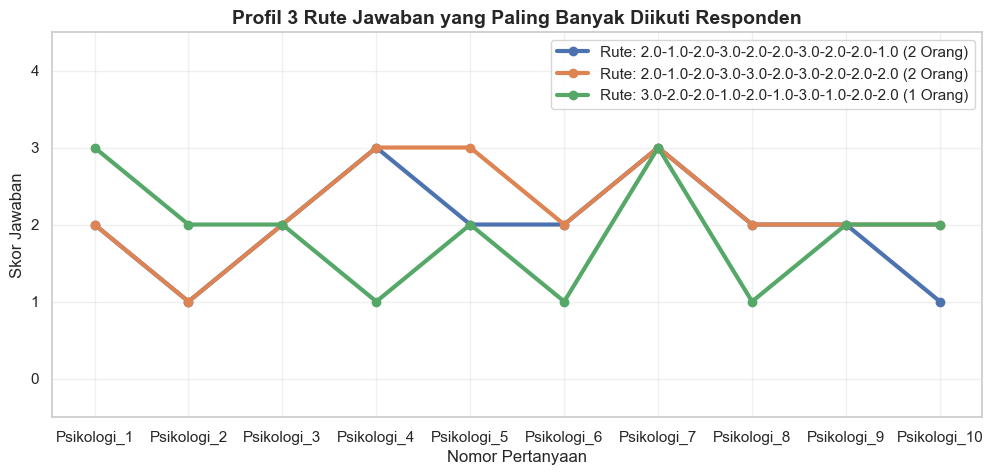

In [14]:
# Ambil 3 rute terbanyak
top_3_rute = df_pss['Rute_Jawaban'].value_counts().head(3).index

plt.figure(figsize=(12, 5))
for rute in top_3_rute:
    # Menggunakan float(x) dulu baru int(x) untuk mengatasi error desimal '2.0'
    angka_rute = [int(float(x)) for x in rute.split('-')]
    jumlah_pengikut = df_pss['Rute_Jawaban'].value_counts()[rute]
    plt.plot(kolom_psikologi, angka_rute, marker='o', linewidth=3, 
             label=f"Rute: {rute} ({jumlah_pengikut} Orang)")

plt.title("Profil 3 Rute Jawaban yang Paling Banyak Diikuti Responden", fontsize=14, fontweight='bold')
plt.xlabel("Nomor Pertanyaan")
plt.ylabel("Skor Jawaban")
plt.ylim(-0.5, 4.5)
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

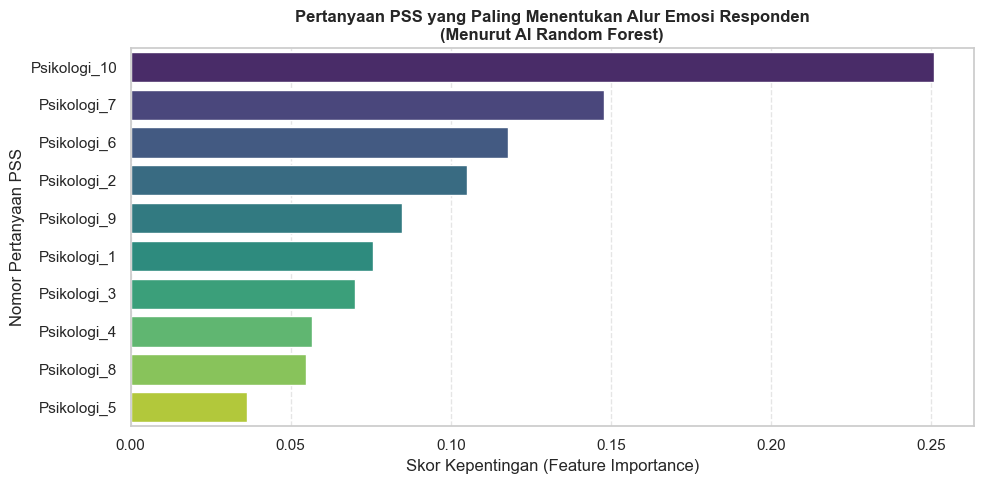

In [15]:
from sklearn.ensemble import RandomForestClassifier

# 1. Menentukan Target Label untuk AI (1 = Alur Alami/Valid, 0 = Alur Anomali/Flat)
# Kita pakai ambang batas korelasi > 0.3 sebagai tanda alurnya searah teori
df_pss['Label_Valid'] = (df_pss['Kemiripan_Teori'] > 0.3).astype(int)

# 2. Memisahkan Fitur (X) dan Target (y)
kolom_psikologi = [f'Psikologi_{i}' for i in range(1, 11)]
X = df_pss[kolom_psikologi]
y = df_pss['Label_Valid']

# 3. Melatih Model AI Random Forest
# Kita gunakan 100 pohon keputusan (n_estimators)
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X, y)

# 4. Mengekstrak Nilai "Feature Importance" (Tingkat Kepentingan Pertanyaan)
importances = rf_model.feature_importances_
df_importance = pd.DataFrame({
    'Pertanyaan': kolom_psikologi,
    'Tingkat_Kepentingan': importances
}).sort_values(by='Tingkat_Kepentingan', ascending=False)

# 5. Visualisasi Hasil Analisis AI (Sudah Diperbaiki dari Warning)
plt.figure(figsize=(10, 5))

# Menambahkan hue='Pertanyaan' dan legend=False sesuai rekomendasi Seaborn terbaru
sns.barplot(
    x='Tingkat_Kepentingan', 
    y='Pertanyaan', 
    data=df_importance, 
    hue='Pertanyaan', 
    palette='viridis', 
    legend=False
)

plt.title('Pertanyaan PSS yang Paling Menentukan Alur Emosi Responden\n(Menurut AI Random Forest)', fontsize=12, fontweight='bold')
plt.xlabel('Skor Kepentingan (Feature Importance)')
plt.ylabel('Nomor Pertanyaan PSS')
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.tight_layout() # Agar teks tidak terpotong di Jupyter
plt.show()

In [16]:
kontradiksi = df_pss[(df_pss['Psikologi_6'] >= 3) & (df_pss['Psikologi_5'] >= 3)]

print(f"Jumlah mahasiswa yang terdeteksi 'Denial' (Stres berat tapi mengaku baik-baik saja): {len(kontradiksi)} orang.")

Jumlah mahasiswa yang terdeteksi 'Denial' (Stres berat tapi mengaku baik-baik saja): 2 orang.


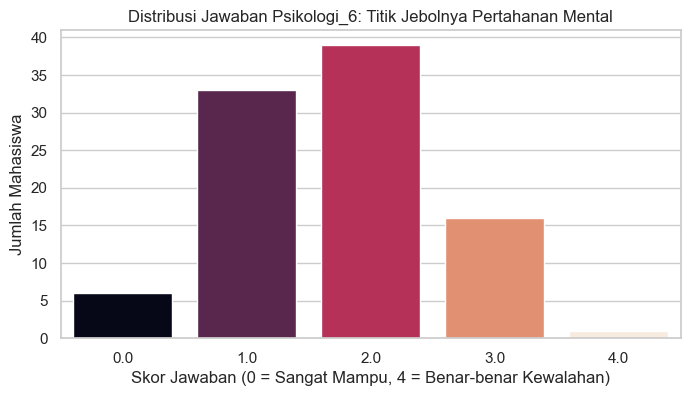

In [17]:
# Cek distribusi jawaban pada pertanyaan nomor 6
plt.figure(figsize=(8, 4))
sns.countplot(x='Psikologi_6', data=df_pss, hue='Psikologi_6', palette='rocket', legend=False)
plt.title('Distribusi Jawaban Psikologi_6: Titik Jebolnya Pertahanan Mental')
plt.xlabel('Skor Jawaban (0 = Sangat Mampu, 4 = Benar-benar Kewalahan)')
plt.ylabel('Jumlah Mahasiswa')
plt.show()

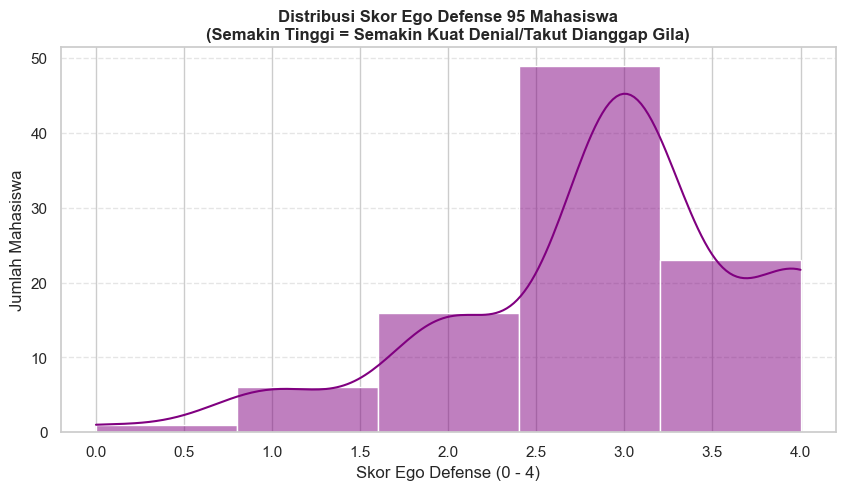

Rata-rata Skor Ego Defense Mahasiswa: 2.92 dari skala 4.00


In [18]:
# Formula: Kita hitung selisih mutlak antara pertanyaan krisis (Psikologi_6) 
# dan pertanyaan koping ideal (Psikologi_5). 
# Jika orang jujur stres: No. 6 tinggi (4), No. 5 rendah (0) -> Selisih = 4 (Konsisten)
# Jika orang denial: No. 6 tinggi (4), No. 5 tinggi (4) -> Selisih = 0 (Kontradiksi/Denial)

df_pss['Skor_Ego_Defense'] = 4 - np.abs(df_pss['Psikologi_6'] - df_pss['Psikologi_5'])

# Visualisasi Distribusi Ego Defense Mahasiswa
plt.figure(figsize=(10, 5))
sns.histplot(data=df_pss, x='Skor_Ego_Defense', kde=True, color='purple', bins=5)

plt.title('Distribusi Skor Ego Defense 95 Mahasiswa\n(Semakin Tinggi = Semakin Kuat Denial/Takut Dianggap Gila)', fontsize=12, fontweight='bold')
plt.xlabel('Skor Ego Defense (0 - 4)')
plt.ylabel('Jumlah Mahasiswa')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()

# Hitung rata-rata ego defense di kampusmu
rata_rata_defense = df_pss['Skor_Ego_Defense'].mean()
print(f"Rata-rata Skor Ego Defense Mahasiswa: {rata_rata_defense:.2f} dari skala 4.00")

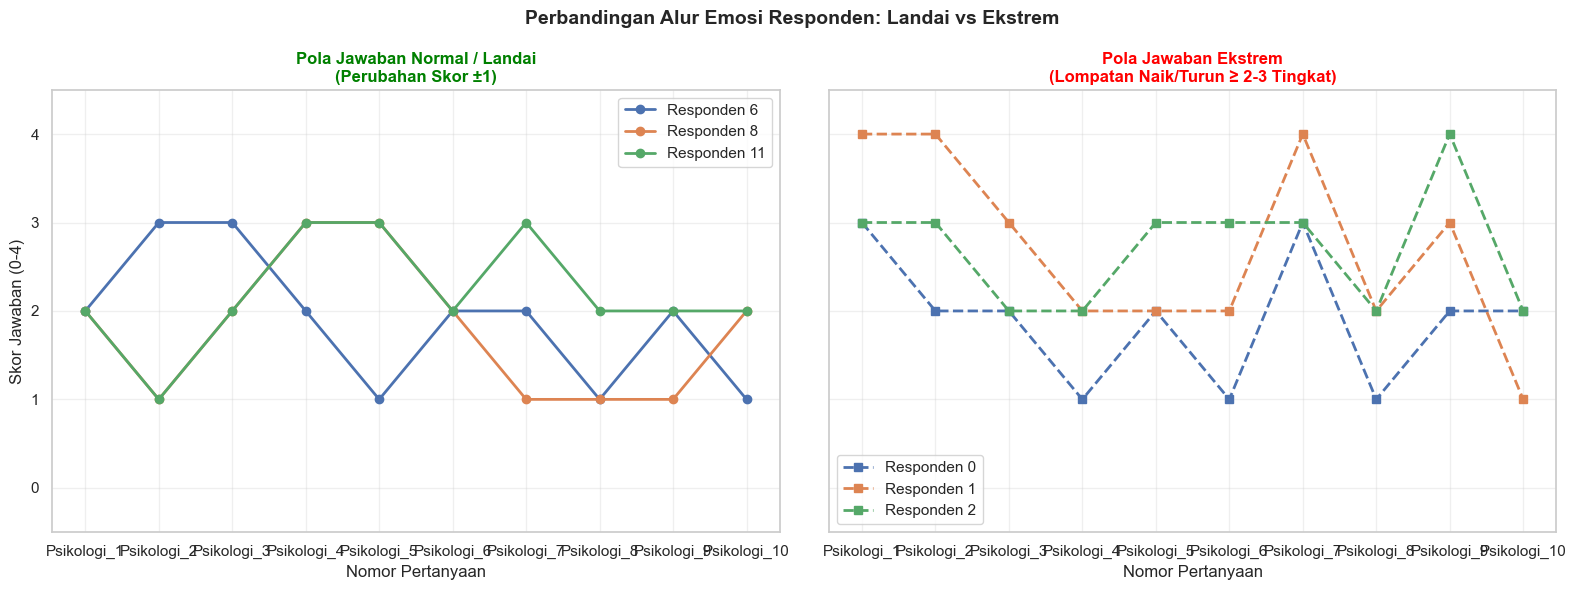

In [19]:
# Nama-nama kolom pertanyaan
kolom_psikologi = [f'Psikologi_{i}' for i in range(1, 11)]

# Hitung lompatan maksimum (selisih terbesar antar pertanyaan berurutan) untuk tiap responden
df_pss['Lompatan_Maks'] = df_pss[kolom_psikologi].apply(lambda row: np.max(np.abs(np.diff(row.values))), axis=1)

# 1. Ambil contoh data Normal/Landai (Lompatan maks hanya 1 tingkat)
data_normal = df_pss[df_pss['Lompatan_Maks'] <= 1].head(3)

# 2. Ambil contoh data Ekstrem (Ada lompatan tajam sebesar 2, 3, atau 4 tingkat)
data_ekstrem = df_pss[df_pss['Lompatan_Maks'] >= 2].head(3)

# ==========================================
# PROSES VISUALISASI GRAFIK
# ==========================================
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6), sharey=True)

# Grafik Kiri: Data Normal / Landai
for idx, row in data_normal.iterrows():
    ax1.plot(kolom_psikologi, row[kolom_psikologi], marker='o', linewidth=2, label=f'Responden {idx}')
ax1.set_title('Pola Jawaban Normal / Landai\n(Perubahan Skor ±1)', fontsize=12, fontweight='bold', color='green')
ax1.set_xlabel('Nomor Pertanyaan')
ax1.set_ylabel('Skor Jawaban (0-4)')
ax1.set_ylim(-0.5, 4.5)
ax1.grid(True, alpha=0.3)
ax1.legend()

# Grafik Kanan: Data Ekstrem / Lompatan Tajam
for idx, row in data_ekstrem.iterrows():
    ax2.plot(kolom_psikologi, row[kolom_psikologi], marker='s', linewidth=2, linestyle='--', label=f'Responden {idx}')
ax2.set_title('Pola Jawaban Ekstrem\n(Lompatan Naik/Turun ≥ 2-3 Tingkat)', fontsize=12, fontweight='bold', color='red')
ax2.set_xlabel('Nomor Pertanyaan')
ax2.grid(True, alpha=0.3)
ax2.legend()

plt.suptitle('Perbandingan Alur Emosi Responden: Landai vs Ekstrem', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [20]:
# Hitung jumlah responden berdasarkan kategori lompatan emosi
total_responden = len(df_pss)
jumlah_ekstrem = len(df_pss[df_pss['Lompatan_Maks'] >= 2])
jumlah_normal = len(df_pss[df_pss['Lompatan_Maks'] <= 1])

persentase_ekstrem = (jumlah_ekstrem / total_responden) * 100

print("=" * 50)
print(f"HASIL AUDIT PERILAKU RESPONDEN (N = {total_responden})")
print("=" * 50)
print(f"1. Kelompok 'Normal/Landai'  : {jumlah_normal} mahasiswa")
print(f"2. Kelompok 'Denial/Ekstrem' : {jumlah_ekstrem} mahasiswa")
print("-" * 50)
print(f"Analisis: Ada {persentase_ekstrem:.1f}% mahasiswa di kampusmu yang")
print("terdeteksi mengalami 'Denial' akibat ketakutan psikologis.")
print("=" * 50)

HASIL AUDIT PERILAKU RESPONDEN (N = 95)
1. Kelompok 'Normal/Landai'  : 16 mahasiswa
2. Kelompok 'Denial/Ekstrem' : 79 mahasiswa
--------------------------------------------------
Analisis: Ada 83.2% mahasiswa di kampusmu yang
terdeteksi mengalami 'Denial' akibat ketakutan psikologis.
